##### Multi-line chart
Data vis 2 on another notebook kasi mas madali siguro toh irun

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Setup REF :: From Live Coding Kit
try:
    import numpy as np
except ImportError as e:
    raise ImportError(
        "This notebook requires numpy. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

try:
    import pandas as pd
except ImportError as e:
    raise ImportError(
        "This notebook requires pandas. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "This notebook requires matplotlib. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "font.size": 11,
    }
)

# Import Data and Set Up Output Folder REF :: From Live Coding Kit

OUT_DIR = Path("notebooks/outputs") if Path("notebooks").is_dir() else Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will be written to:", OUT_DIR.resolve())

# Locate the class dataset regardless of whether you're running from repo root or `notebooks/`.
DATA_CANDIDATES = [
    Path("202512_CombinedData.csv"),
    Path("DATA101 Notebook\202512_CombinedData.csv"),
]
for _p in DATA_CANDIDATES:
    if _p.exists():
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        "Could not find data-task-abstraction-dataset.csv. "
        "Expected it in `notebooks/` (recommended) or the current folder."
    )

df = pd.read_csv(DATA_PATH)

Outputs will be written to: C:\Users\kiwib\Desktop\DATA101 Notebook\outputs


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102669 entries, 0 to 102668
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype                    
---  ------            --------------   -----                    
 0   datetime          102669 non-null  datetime64[us, UTC+08:00]
 1   main.aqi          102669 non-null  float64                  
 2   components.co     102669 non-null  float64                  
 3   components.no     102669 non-null  float64                  
 4   components.no2    102669 non-null  float64                  
 5   components.o3     102669 non-null  float64                  
 6   components.so2    102669 non-null  float64                  
 7   components.pm2_5  102669 non-null  float64                  
 8   components.pm10   102669 non-null  float64                  
 9   components.nh3    102669 non-null  float64                  
 10  city_name         102669 non-null  str                      
 11  date              102669 non-null  ob

city_name   Alaminos  Angeles City  Antipolo   Bacolod    Bacoor  Bago City    Baguio      Bais   Balanga  Batac City  Batangas City  \
date                                                                                                                                   
2025-12-01  2.250000      2.500000  2.833333  1.166667  2.791667   1.000000  2.833333  1.000000  2.416667    1.958333       1.958333   
2025-12-02  2.166667      2.916667  3.416667  1.291667  3.250000   1.333333  2.291667  1.208333  3.041667    1.583333       2.916667   
2025-12-03  2.000000      2.500000  2.458333  1.000000  2.833333   1.000000  2.000000  1.000000  2.666667    2.000000       2.625000   
2025-12-04  2.125000      2.166667  1.875000  1.208333  1.958333   1.041667  2.125000  1.000000  2.166667    2.000000       1.750000   
2025-12-05  2.208333      2.333333  2.125000  2.000000  2.208333   2.000000  2.083333  1.750000  2.333333    2.000000       2.000000   

city_name    Bayawan    Baybay  Bayugan    Bisl

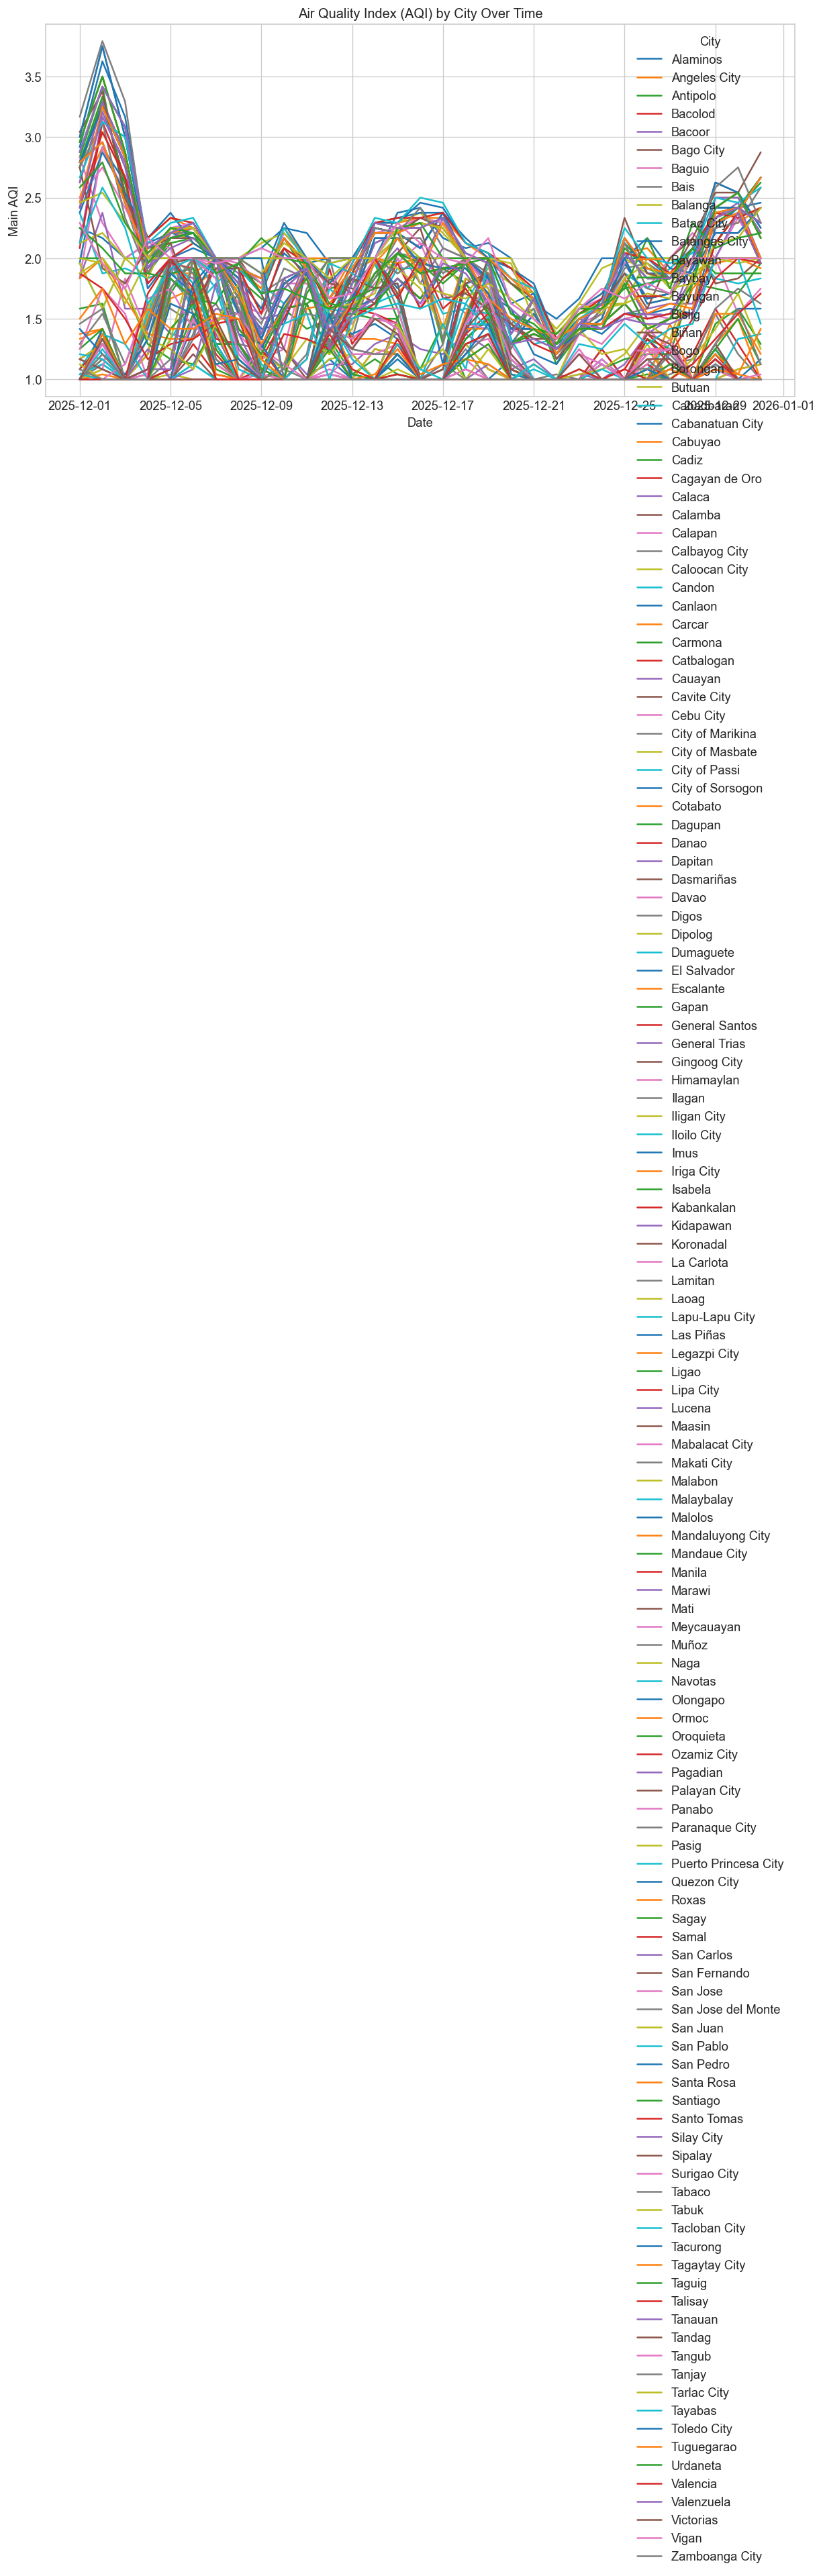

In [ ]:
# Convert datetime to date only
df['date'] = pd.to_datetime(df['datetime']).dt.date

# Aggregate by date and city
daily_df = df.groupby(['date', 'city_name'])['main.aqi'].mean().reset_index()

# Pivot the aggregated data
pivot_df = daily_df.pivot(index='date', columns='city_name', values='main.aqi')

print(pivot_df.head())
print(pivot_df.info())

# Plot
pivot_df.plot(figsize=(12,6))
plt.title("Air Quality Index (AQI) by City Over Time")
plt.xlabel("Date")
plt.ylabel("Main AQI")
plt.legend(title="City")
plt.grid(True)
plt.show()